# 04 — XGBoost Detector (Structural Features)
**Feature set (14):**
`has_{form,input,label,iframe,style}` · `input_count` · `label_count` · `form_count` · `button_count` ·
`signature_length` · `total_tag_count` · `form_density` · `input_per_form` · `has_credential_pattern`

**No leakage:** structural features are computed per-row (independent of other pages), so there is no
feature-selection step that could leak the test set. Retest labels are derived from the `label`
column, not file of origin.

- **Train:** `train_login_form-2026-08.csv` + `train_no_form-2026-08.csv` (deduplicated)
- **Retest:** `signed_retest_login_form.csv` + `signed_retest_no_form.csv` (held-out, unseen)

In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mlflow
import mlflow.xgboost
import warnings
warnings.filterwarnings("ignore")

from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, precision_recall_fscore_support, accuracy_score
)

import sys
sys.path.insert(0, '../../src')
from features import CREDENTIAL_GROUP, STRUCTURAL_COLS, structural_features

RANDOM_STATE = 42

In [2]:
from pathlib import Path
_DB = Path("../../mlflow.db").resolve()
mlflow.set_tracking_uri(f"sqlite:///{_DB}")
if mlflow.active_run():
    mlflow.end_run()
mlflow.set_experiment("login-form-detection")
_active_run = mlflow.start_run(run_name="structural-xgboost")
print(f"Tracking URI : {mlflow.get_tracking_uri()}")
print(f"MLflow run   : {_active_run.info.run_id[:8]}")

Tracking URI : sqlite:////Users/nelson.mutua/Desktop/ThreatLabz/Login_Forms_Detection/mlflow.db
MLflow run   : 55eea624


## 1. Load & Clean Data

In [3]:
# load training data (login_form is semicolon-delimited; no_form is comma-delimited)
lf = pd.read_csv("../../data/train/train_login_form-2026-08.csv", sep=";")
nf = pd.read_csv("../../data/train/train_no_form-2026-08.csv", index_col=0)

if "schreenshot_path" in nf.columns:
    nf.drop(columns=["schreenshot_path"], inplace=True)
lf.dropna(subset=["html_signature"], inplace=True)
nf.dropna(subset=["html_signature"], inplace=True)
lf.reset_index(drop=True, inplace=True)
nf.reset_index(drop=True, inplace=True)

df = pd.concat([lf, nf], ignore_index=True)
df = df.drop_duplicates(subset=["html_signature"]).reset_index(drop=True)
df["binary_label"] = (df["label"] == "LOGIN_FORM_MALICIOUS").astype(int)

print(f"Train dataset (deduplicated): {len(df)} rows | "
      f"Malicious: {df['binary_label'].sum()} | No-Form: {(df['binary_label']==0).sum()}")

Train dataset (deduplicated): 2072 rows | Malicious: 878 | No-Form: 1194


## 2. Structural Feature Extraction

In [4]:
df = structural_features(df)

print(f"Structural features : {len(STRUCTURAL_COLS)}")
print("\nMean by class:")
display(df.groupby("label")[STRUCTURAL_COLS].mean().round(3).T)

Structural features : 14

Mean by class:


label,LOGIN_FORM_MALICIOUS,NO_FORM
has_form,0.940,0.632
has_input,0.983,0.763
has_label,0.849,0.578
has_iframe,0.543,0.740
has_style,0.567,0.615
input_count,7.843,30.503
label_count,3.579,19.141
form_count,1.216,3.197
button_count,2.990,31.096
signature_length,1173.031,8649.126


## 3. Train / Test Split

In [5]:
X = df[STRUCTURAL_COLS].values
y = df["binary_label"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print(f"Feature matrix : {X.shape}  ({len(STRUCTURAL_COLS)} structural features)")
print(f"Train : {X_train.shape[0]} rows | Malicious: {y_train.sum()} | No-Form: {(y_train==0).sum()}")
print(f"Test  : {X_test.shape[0]} rows  | Malicious: {y_test.sum()} | No-Form: {(y_test==0).sum()}")

Feature matrix : (2072, 14)  (14 structural features)
Train : 1657 rows | Malicious: 702 | No-Form: 955
Test  : 415 rows  | Malicious: 176 | No-Form: 239


## 4. Train XGBoost

In [6]:
model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=RANDOM_STATE,
    n_jobs=-1
)

model.fit(X_train, y_train)
print("Model trained.")

Model trained.


## 5. Evaluation


Train Set


,Precision,Recall,F1-Score,Support
Class,,,,
NO_FORM,98.4%,99.1%,98.7%,955
LOGIN_FORM_MALICIOUS,98.7%,97.9%,98.3%,702
Accuracy,,,98.6%,1657
ROC-AUC,,,99.9%,



Test Set


,Precision,Recall,F1-Score,Support
Class,,,,
NO_FORM,92.9%,93.3%,93.1%,239
LOGIN_FORM_MALICIOUS,90.9%,90.3%,90.6%,176
Accuracy,,,92.0%,415
ROC-AUC,,,96.4%,


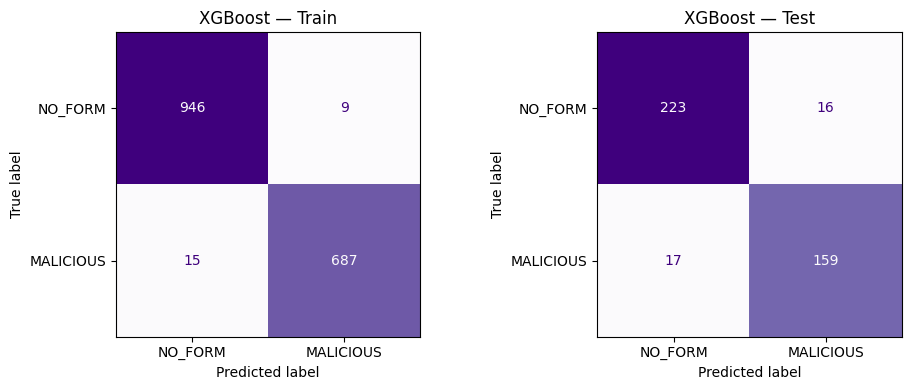

In [7]:
classes = ["NO_FORM", "LOGIN_FORM_MALICIOUS"]

def report_table(y_true, y_pred, y_prob, label):
    prec, rec, f1, sup = precision_recall_fscore_support(y_true, y_pred)
    acc = accuracy_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_prob)
    rows = []
    for i, cls in enumerate(classes):
        rows.append({"Class": cls, "Precision": f"{prec[i]*100:.1f}%",
                     "Recall": f"{rec[i]*100:.1f}%", "F1-Score": f"{f1[i]*100:.1f}%",
                     "Support": int(sup[i])})
    rows.append({"Class": "Accuracy", "Precision": "", "Recall": "",
                 "F1-Score": f"{acc*100:.1f}%", "Support": int(sup.sum())})
    rows.append({"Class": "ROC-AUC", "Precision": "", "Recall": "",
                 "F1-Score": f"{auc*100:.1f}%", "Support": ""})
    print(f"\n{label}")
    display(pd.DataFrame(rows).set_index("Class"))
    return acc, auc

y_train_pred = model.predict(X_train)
y_train_prob = model.predict_proba(X_train)[:, 1]
y_test_pred  = model.predict(X_test)
y_test_prob  = model.predict_proba(X_test)[:, 1]

train_acc, train_auc = report_table(y_train, y_train_pred, y_train_prob, "Train Set")
test_acc,  test_auc  = report_table(y_test,  y_test_pred,  y_test_prob,  "Test Set")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, y_t, y_p, title in [
    (axes[0], y_train, y_train_pred, "Train"),
    (axes[1], y_test,  y_test_pred,  "Test"),
]:
    cm = confusion_matrix(y_t, y_p)
    ConfusionMatrixDisplay(cm, display_labels=["NO_FORM", "MALICIOUS"]).plot(
        ax=ax, colorbar=False, cmap="Purples")
    ax.set_title(f"XGBoost — {title}")
plt.tight_layout()
plt.show()

## 6. Retest on Unseen Data

In [8]:
lf_rt = pd.read_csv("../../data/retest/signed_retest_login_form.csv", index_col=0)
nf_rt = pd.read_csv("../../data/retest/signed_retest_no_form.csv", index_col=0)

for df_ in [lf_rt, nf_rt]:
    for junk in ("Unnamed: 0", "schreenshot_path"):
        if junk in df_.columns:
            df_.drop(columns=[junk], inplace=True)

df_rt = pd.concat([lf_rt, nf_rt], ignore_index=True)
df_rt.dropna(subset=["html_signature"], inplace=True)
df_rt.reset_index(drop=True, inplace=True)

# derive label from the `label` column (TEST_LOGIN_FORM -> 1), not file of origin
df_rt["binary_label"] = df_rt["label"].str.contains("LOGIN_FORM", case=False, na=False).astype(int)

df_rt = structural_features(df_rt)

print(f"Retest dataset : {len(df_rt)} rows | "
      f"Malicious: {df_rt['binary_label'].sum()} | No-Form: {(df_rt['binary_label']==0).sum()}")

Retest dataset : 208 rows | Malicious: 109 | No-Form: 99


In [9]:
X_rt = df_rt[STRUCTURAL_COLS].values
y_rt = df_rt["binary_label"].values

y_rt_pred = model.predict(X_rt)
y_rt_prob = model.predict_proba(X_rt)[:, 1]

prec, rec, f1, sup = precision_recall_fscore_support(y_rt, y_rt_pred)
acc = accuracy_score(y_rt, y_rt_pred)
auc = roc_auc_score(y_rt, y_rt_prob)

rows = []
for i, cls in enumerate(classes):
    rows.append({"Class": cls, "Precision": f"{prec[i]*100:.1f}%",
                 "Recall": f"{rec[i]*100:.1f}%", "F1-Score": f"{f1[i]*100:.1f}%",
                 "Support": int(sup[i])})
rows.append({"Class": "Accuracy", "Precision": "", "Recall": "",
             "F1-Score": f"{acc*100:.1f}%", "Support": int(sup.sum())})
rows.append({"Class": "ROC-AUC",  "Precision": "", "Recall": "",
             "F1-Score": f"{auc*100:.1f}%", "Support": ""})

print("Retest Classification Report")
display(pd.DataFrame(rows).set_index("Class"))

Retest Classification Report


,Precision,Recall,F1-Score,Support
Class,,,,
NO_FORM,92.3%,72.7%,81.4%,99
LOGIN_FORM_MALICIOUS,79.2%,94.5%,86.2%,109
Accuracy,,,84.1%,208
ROC-AUC,,,92.2%,


In [10]:
mlflow.log_metrics({
    "train_accuracy":       train_acc,
    "test_accuracy":        test_acc,
    "retest_accuracy":      acc,
    "train_roc_auc":        train_auc,
    "test_roc_auc":         test_auc,
    "retest_roc_auc":       auc,
    "retest_mal_precision": float(prec[1]),
    "retest_mal_recall":    float(rec[1]),
    "retest_mal_f1":        float(f1[1]),
})
print("Metrics logged to MLflow.")

Metrics logged to MLflow.


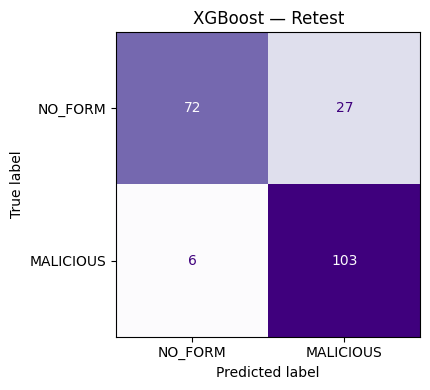


False Positives : 27  (NO_FORM flagged as Malicious)
False Negatives : 6  (Malicious Login Forms missed)

--- False Positives (sample) ---


,url,html_signature
106,http://anyacloudflare.akuanakmamah.de.dm-manag...,(body(div(div(img)(img)(div(img)))(div(div(img...
108,http://authorize-desire-clarity.vercel.app,(body(app-root(div(router-outlet)(app-business...
109,http://bestoflifeyou.duckdns.org/securepage.php,(body(div)(div(div(div)(a)(div)(div(div(div(di...
112,http://bsodxd2025.myauth.rocks,(body(div)(main(div(div(img))(script)(script)(...
117,http://helplive-ledger.com,(body(div)(div(div(img)(div(button(svg(path)))...
119,http://ijikc.co.in/sites/ijikc20/rating/ken7xx...,(body(a)(div)(div(style)(div(a))(div(div(scrip...
120,http://layanan.dana-indonesia.top,(body(div(div(img))(div(div(img))(div)(button)...
122,http://lonesis-345534-ghibanto-lipoka.pages.de...,(body(div(div(div(div))(div(div(div(center))(d...
129,http://o2secure.realestatecoachinghub.com,(body(style)(div(div(header(div(div(div(a))(ul...
135,https://actionvalidationrequired0.godaddysites...,(body(div(div(div(div(div(div(div(div(div(styl...



--- False Negatives (sample) ---


,url,html_signature
14,http://payment.smbstaging.enterprisedeliveries...,(body(header(div(div(a(img)))(div(div(div(butt...
21,https://airbnb-89373reservation.com/2061969605,(body(div(div(iframe)))(div)(script)(div(div(a...
22,https://alareentading-catalog.page.tl,(body(div(div(div(div(div(div)(div)))(div)))(d...
23,https://api.9009000.com/login,(body(div(div(div))(div))(div(svg(mask(path))(...
38,https://fake-verification.vercel.app,(body(div(div)(div))(div(svg(mask(path))(mask(...
95,https://www.bmle545.services/account/login?spm...,(body(style)(div(svg(g(path))))(spz-observer)(...


In [11]:
cm_rt = confusion_matrix(y_rt, y_rt_pred)
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(confusion_matrix=cm_rt, display_labels=["NO_FORM", "MALICIOUS"]).plot(
    ax=ax, colorbar=False, cmap="Purples")
ax.set_title("XGBoost — Retest")
plt.tight_layout()
plt.show()

fp_rt = df_rt[(y_rt_pred == 1) & (y_rt == 0)]
fn_rt = df_rt[(y_rt_pred == 0) & (y_rt == 1)]

print(f"\nFalse Positives : {len(fp_rt)}  (NO_FORM flagged as Malicious)")
print(f"False Negatives : {len(fn_rt)}  (Malicious Login Forms missed)")

if len(fp_rt):
    print("\n--- False Positives (sample) ---")
    display(fp_rt[["url", "html_signature"]].head(10))

if len(fn_rt):
    print("\n--- False Negatives (sample) ---")
    display(fn_rt[["url", "html_signature"]].head(10))

## 7. Save Model

In [12]:
import joblib
from pathlib import Path

MODELS_DIR = Path("../../models")
MODELS_DIR.mkdir(exist_ok=True)

joblib.dump(model, MODELS_DIR / "structural_xgboost.pkl")

mlflow.log_params({
    "n_estimators":    model.n_estimators,
    "max_depth":       model.max_depth,
    "learning_rate":   model.learning_rate,
    "subsample":       model.subsample,
    "colsample_bytree": model.colsample_bytree,
    "feature_track":   "structural_14features",
    "random_state":    RANDOM_STATE,
})
mlflow.xgboost.log_model(model, "model")
mlflow.end_run()

print(f"Saved → models/structural_xgboost.pkl")
print("MLflow run complete.")

2026/09/07 10:48:08 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Saved → models/structural_xgboost.pkl
MLflow run complete.
